In [3]:
%pip install -q -r requirements.txt

  DEPRECATION: Building 'filterpy' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'filterpy'. Discussion can be found at https://github.com/pypa/pip/issues/6334
Note: you may need to restart the kernel to use updated packages.


In [1]:
import gymnasium as gym
import highway_env

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from collections import namedtuple

# Visualization
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm.notebook import trange

# IO
from pathlib import Path
import json

In [ ]:
!pip install <rl-agents_repo_url>  # Replace with the actual URL of the rl-agents repository

In [14]:
from pathlib import Path

# Patch logger.py

logger_path = Path("rl-agents/rl_agents/trainer/logger.py")
logger_text = logger_path.read_text()
# Replace default argument value
logger_text = logger_text.replace("gym_level=gym.logger.INFO", "gym_level=__import__('logging').INFO")
# Remove any line that tries to set the gym logger level
logger_lines = logger_text.splitlines()
logger_lines = [line for line in logger_lines if "gym.logger.set" not in line]
# Write back the patched file
logger_path.write_text("\n".join(logger_lines))

# Patch evaluation.py: remove broken import and define capped_cubic_video_schedule
eval_path = Path("rl-agents/rl_agents/trainer/evaluation.py")
eval_text = eval_path.read_text()


eval_text = eval_text.replace("np.infty", "np.inf")
eval_text = eval_text.replace(
    "from gymnasium.wrappers import RecordVideo, RecordEpisodeStatistics, capped_cubic_video_schedule",
    "from gymnasium.wrappers import RecordVideo, RecordEpisodeStatistics"
)

inject_fn = """

def capped_cubic_video_schedule(episode_id):
    return True
"""

eval_lines = eval_text.splitlines()
for i, line in enumerate(eval_lines):
    if not line.strip().startswith("import") and not line.strip().startswith("from"):
        inject_index = i
        break
eval_lines = eval_lines[:inject_index] + [inject_fn.strip()] + eval_lines[inject_index:]
eval_path.write_text("\n".join(eval_lines))



16612

In [2]:
import base64
from pathlib import Path

from gymnasium.wrappers import RecordVideo
from IPython import display as ipythondisplay
# from pyvirtualdisplay import Display


# display = Display(visible=0, size=(1400, 900))
# display.start()


def record_videos(env, video_folder="videos"):
    wrapped = RecordVideo(
        env, video_folder=video_folder, episode_trigger=lambda e: True
    )

    # Capture intermediate frames
    env.unwrapped.set_record_video_wrapper(wrapped)

    return wrapped


def show_videos(path="videos"):
    html = []
    for mp4 in Path(path).glob("*.mp4"):
        video_b64 = base64.b64encode(mp4.read_bytes())
        html.append(
            """<video alt="{}" autoplay
                      loop controls style="height: 400px;">
                      <source src="data:video/mp4;base64,{}" type="video/mp4" />
                 </video>""".format(
                mp4, video_b64.decode("ascii")
            )
        )
    ipythondisplay.display(ipythondisplay.HTML(data="<br>".join(html)))

In [5]:
Transition = namedtuple('Transition', ['state', 'action', 'next_state'])

def collect_interaction_data(env, size=5, action_repeat=2):
# def collect_interaction_data(env, size=1000, action_repeat=2):
    data, done = [], True
    for _ in trange(size, desc="Collecting interaction data"):
        action = env.action_space.sample()
        for _ in range(action_repeat):
            if done:
              previous_obs, info = env.reset()
            obs, reward, done, truncated, info = env.step(action)
            # print("obs:", obs)
            # print("reward:", reward)
            # print("previous_obs:", previous_obs)
            # break
            data.append(Transition(torch.Tensor(previous_obs),
                                   torch.Tensor(action),
                                   torch.Tensor(obs)))
            previous_obs = obs
        # break
    return data

env = gym.make("roundabout-v0")
data = collect_interaction_data(env)
env.close()
print("Sample transition:", data[0])

Sample transition: Transition(state=tensor([[ 1.0000e+00,  2.0000e-02,  4.5000e-01,  0.0000e+00, -5.3333e-01],
        [ 1.0000e+00, -2.5596e-02,  1.9836e-01,  9.4563e-01,  1.2202e-01],
        [ 1.0000e+00, -1.9506e-01,  1.3983e-01,  5.5461e-01,  7.7368e-01],
        [ 1.0000e+00,  1.0000e+00, -2.0000e-02, -9.9214e-01,  2.2204e-16],
        [ 1.0000e+00, -1.6770e-01, -1.0897e-01, -6.8975e-01,  1.0000e+00]]), action=tensor([0.]), next_state=tensor([[ 1.0000e+00,  2.5094e-02,  3.7028e-01,  5.7208e-02, -5.3026e-01],
        [ 1.0000e+00, -8.1844e-02,  2.2365e-01,  8.6496e-01,  3.9751e-01],
        [ 1.0000e+00,  1.1039e-01,  1.6412e-01,  8.3871e-01, -4.5350e-01],
        [ 1.0000e+00, -1.8591e-01,  7.3315e-02,  3.4723e-01,  1.0000e+00],
        [ 1.0000e+00,  1.0000e+00, -2.0000e-02, -9.9214e-01,  2.2204e-16]]))


In [9]:
# %cd ../
# ! pip install -e .

# Run Once
config_root = Path("rl-agents/scripts/configs")

# Traverse all .json files recursively
for json_path in config_root.rglob("*.json"):
    try:
        content = json.loads(json_path.read_text())
        content_str = json.dumps(content)

        if "rl_agents.agents.tree_search.robust" in content_str:
            # Replace all references to the outdated path
            content_str = content_str.replace(
                "rl_agents.agents.tree_search.robust",
                "rl_agents.agents.robust.robust"
            )
            # Write back the updated content
            json_path.write_text(json.dumps(json.loads(content_str), indent=2))
            print(f"✔️ Patched: {json_path}")
    except Exception as e:
        print(f"⚠️ Skipped {json_path}: {e}")

⚠️ Skipped rl-agents/scripts/configs/HighwayEnv/agents/MCTSAgent/iterations50.json: Expecting property name enclosed in double quotes: line 4 column 1 (char 95)


In [7]:
class DynamicsModel(nn.Module):
    STATE_X = 0
    STATE_Y = 1

    def __init__(self, state_size, action_size, hidden_size, dt):
        super().__init__()
        self.state_size, self.action_size, self.dt = state_size, action_size, dt
        A_size, B_size = state_size * state_size, state_size * action_size
        self.A1 = nn.Linear(state_size + action_size, hidden_size)
        self.A2 = nn.Linear(hidden_size, A_size)
        self.B1 = nn.Linear(state_size + action_size, hidden_size)
        self.B2 = nn.Linear(hidden_size, B_size)

    def forward(self, x, u):
        """
            Predict x_{t+1} = f(x_t, u_t)
        :param x: a batch of states
        :param u: a batch of actions
        """
        # print(x.shape, u.shape)
        xu = torch.cat((x, u), -1)
        xu[:, self.STATE_X:self.STATE_Y+1] = 0  # Remove dependency in (x,y)
        A = self.A2(F.relu(self.A1(xu)))
        A = torch.reshape(A, (x.shape[0], self.state_size, self.state_size))
        B = self.B2(F.relu(self.B1(xu)))
        B = torch.reshape(B, (x.shape[0], self.state_size, self.action_size))
        dx = A @ x.unsqueeze(-1) + B @ u.unsqueeze(-1)
        return x + dx.squeeze()*self.dt

state_size = 25
dynamics_model = DynamicsModel(state_size=state_size,
                         action_size=env.action_space.n,
                         hidden_size=64,
                         dt=1/env.unwrapped.config["policy_frequency"])
print(env.observation_space.shape[0], env.action_space.n)
# print("Forward initial model on a sample transition:", dynamics(data[0].state.unsqueeze(0),
#                                                                 data[0].action.unsqueeze(0)).detach())

5 5


In [ ]:
from torch.distributions.categorical import Categorical

def one_hot(a, n_classes):
    return F.one_hot(a.long(), num_classes=n_classes).float()

def reward_fn(state):
    # highway‑env state layout: [x, y, vx, vy, heading, steering, ...]
    y_pos = state[..., 1]
    speed = torch.linalg.vector_norm(state[..., 2:4], dim=-1)   # vx, vy
    reward = 1.0 - y_pos.abs() - 0.02 * speed
    return reward

# Sample cem_planner
def cem_planner(x0, action_dim, model, planning_horizon=15, iterations=5, samples=500, topk=50, alpha=0.25):
    x0 = x0.flatten()
    # print(x0.shape)
    logits = torch.zeros(planning_horizon, action_dim)
    for _ in range(iterations):
        # 3.1 sample sequences
        a_seq = Categorical(logits=logits.unsqueeze(0).expand(samples, -1, -1)).sample() # [samples, horizon]
        # print(f"a_seq: {a_seq.shape}")
                
        # 3.2 roll out
        cum_r = torch.zeros(samples)
        state = x0.repeat(samples, 1) # [samples, state_dim]

        for t in range(planning_horizon):
            a_t    = a_seq[:, t]
            # print(f"a_t: {a_t.shape}")
            a_oneh = one_hot(a_t, action_dim)
            # print(f"a_oneh: {a_oneh.shape}")
            # print(f"state: {state.shape}")
            state  = model(state, a_oneh)
            cum_r += reward_fn(state)

        # 3.3 elite selection
        elite_idx = torch.topk(cum_r, topk).indices
        elite_seq = a_seq[elite_idx] # [topk, horizon]

        # 3.4 update logits with smoothing
        counts = torch.bincount(
            elite_seq.view(-1),
            minlength=planning_horizon * action_dim
        ).view(planning_horizon, action_dim).float() + 1e-6
        new_logits = torch.log(counts)
        logits = (1 - alpha) * logits + alpha * new_logits

    # 4. return the MAP first action
    return logits[0].argmax()

env = gym.make("roundabout-v0", render_mode='rgb_array')
# env = record_videos(env)
obs, info = env.reset()

num_episodes = 100
episode_rewards = []

for episode in trange(num_episodes, desc=f"Testing {num_episodes} episodes..."):
    obs, info = env.reset()
    total_reward = 0

    done, truncated = False, False
    while not (done or truncated):
        action = cem_planner(
            torch.tensor(obs, dtype=torch.float32),
            env.action_space.n,
            model=dynamics_model
        )
        obs, reward, done, truncated, info = env.step(action)
        total_reward += reward

    episode_rewards.append(total_reward)

env.close()

Testing 100 episodes...:   0%|          | 0/100 [00:00<?, ?it/s]

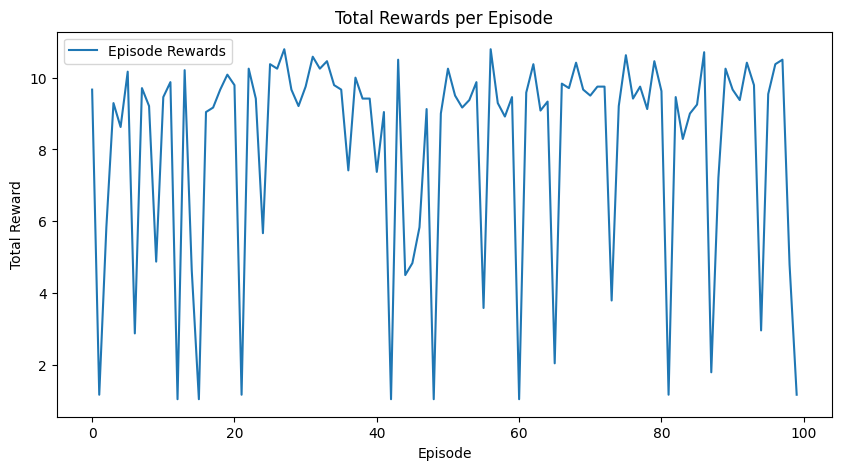

In [11]:
# print(rewards)
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, label='Episode Rewards')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Total Rewards per Episode')
plt.legend()
plt.show()

In [9]:
print(type(obs), obs)

<class 'numpy.ndarray'> [[ 1.0000000e+00  6.8172365e-02  2.3654354e-01  1.5759036e-01
  -5.2600950e-01]
 [ 1.0000000e+00  1.0930104e-01  2.0470355e-01  6.3927186e-01
  -1.6864706e-02]
 [ 1.0000000e+00  1.9323355e-01  4.2066097e-02  3.0814257e-01
  -9.4440246e-01]
 [ 1.0000000e+00  8.1829625e-01 -2.0000000e-02 -1.0000000e+00
   2.2204460e-16]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
   0.0000000e+00]]


In [5]:
# %cd scripts
!python experiments.py evaluate configs/RoundaboutEnv/env.json configs/RoundaboutEnv/agents/IntervalRobustPlannerAgent/behaviours.json --test --episodes=5 --no-display --noisy

configs/RoundaboutEnv/agents/IntervalRobustPlannerAgent/behaviours.json
[INFO] Episode 0 score: 71.5 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[INFO] Episode 1 score: 11.0 
[INFO] Episode 2 score: 71.8 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[W

Our Code

In [3]:
%cd rl-agents/scripts/

/Users/Jay/UT/Courses/CS378_GeomFdtnsofDS/new_repo/rl-agents/scripts


In [62]:
from rl_agents.agents.common.factory import load_environment, load_agent
from rl_agents.trainer.evaluation import Evaluation
from rl_agents.trainer import logger
import os
from pathlib import Path
import time


def step(evaluator, noise_std):
    if noise_std is not None:
        # print("OBS:", evaluator.observation.shape)
        # print('Pre Noise:  ', evaluator.observation.mean(), evaluator.observation.std())
        noise = np.random.normal(0, noise_std, size=evaluator.observation.shape)
        evaluator.observation += noise
        # print('With Noise: ', evaluator.observation.mean(), evaluator.observation.std())
    
    actions = evaluator.agent.plan(evaluator.observation)
    if not actions:
        raise Exception("The agent did not plan any action")

    # Forward the actions to the environment viewer
    try:
        evaluator.env.unwrapped.viewer.set_agent_action_sequence(actions)
    except AttributeError:
        pass

    # Step the environment
    previous_observation, action = evaluator.observation, actions[0]
    transition = evaluator.wrapped_env.step(action)
    evaluator.observation, reward, done, truncated, info = transition

    terminal = done or truncated

    # Record the experience.
    try:
        evaluator.agent.record(previous_observation, action, reward, evaluator.observation, done, info)
    except NotImplementedError:
        pass

    return reward, terminal

def reset(evaluator, seed):
    seed = evaluator.sim_seed + seed
    evaluator.observation, info = evaluator.wrapped_env.reset()
    evaluator.agent.seed(seed)  # Seed the agent with the main environment seed
    evaluator.agent.reset()

def test(evaluator, episodes, noise_std=None, metric_fn=None):
    returns, collisions, errs, acts = [], [], [], []   # errs will stay empty

    if evaluator.display_env:
        evaluator.wrapped_env.episode_trigger = lambda e: True
    try:
        evaluator.agent.eval()
    except AttributeError:
        pass

    for ep in range(episodes):
        evaluator.reset(seed=ep)
        done, ep_return = False, 0.0
        ep_actions, ep_collision = [], 0

        while not done:
            # optional synthetic noise -------------------------------
            if noise_std is not None:
                evaluator.observation += np.random.normal(
                    0, noise_std, evaluator.observation.shape)
            # --------------------------------------------------------

            # plan & step
            actions = evaluator.agent.plan(evaluator.observation)
            ep_actions.append(actions[0])
            tr = evaluator.wrapped_env.step(actions[0])
            evaluator.observation, reward, done, truncated, info = tr
            ep_return += reward
            done = done or truncated
            if info.get("crashed", False):
                ep_collision = 1

        returns.append(ep_return)
        collisions.append(ep_collision)
        acts.append(ep_actions)
        print(f"Episode {ep} score: {ep_return:.1f}")

    evaluator.wrapped_env.close()
    # errors list left empty to mimic signature
    if metric_fn is not None:
        metrics = metric_fn(returns,
                                collision_flags=collisions,
                                kf_errs=[],          # no KF errors
                                actions=acts)
    else:
        metrics = returns
    return metrics

def run_evaluation(env_config, agent_config, num_episodes=5, display=False, noise=None, metric_fn=None):
    # Load environment and agent
    env = load_environment(env_config)
    agent = load_agent(agent_config, env)
    
    # Create run directory name
    run_directory = f"evaluation_{Path(agent_config.get('__class__', 'unknown')).stem}_{os.getpid()}"
    
    # Create and run evaluation
    evaluator = Evaluation(
        env=env,
        agent=agent,
        run_directory=run_directory,
        num_episodes=num_episodes,
        sim_seed=42,
        recover=False,
        display_env=display,
        display_agent=display,
        display_rewards=display,
        noise=noise
    )
    
    metrics = test(evaluator, episodes=num_episodes, noise_std=noise, metric_fn=metric_fn)    
    return os.path.relpath(evaluator.run_directory), metrics


In [10]:
env_config = {
    "id": "roundabout-v0",
    "import_module": "highway_env",
    "other_vehicles_type": "highway_env.vehicle.behavior.LinearVehicle",
    "lanes_count": 4,
    "vehicles_count": 5,
    "duration": 40,
    "policy_frequency": 2,
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 5,
        "features": [
            "presence",
            "x",
            "y",
            "vx",
            "vy",
            "cos_h",
            "sin_h"
        ],
        "absolute": False
    },
    "render_mode": "rgb_array"
}

agent_config = {
  "__class__": "<class 'rl_agents.agents.robust.robust.IntervalRobustPlannerAgent'>",
  "env_preprocessors": [
    {
      "method": "change_vehicles",
      "args": "highway_env.vehicle.uncertainty.estimation.RegressionVehicle"
    }
  ],
  "sub_agent_path": "rl-agents/scripts/configs/RoundaboutEnv/agents/DeterministicPlannerAgent/baseline.json",
  "enable_robust_planning": True
}

results_dir, scores = run_evaluation(env_config, agent_config, num_episodes=20, display=False, noise=0.5)

/Users/Jay/.local/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /Users/Jay/UT/Courses/CS378_GeomFdtnsofDS/new_repo/out/RoundaboutEnv/IntervalRobustPlannerAgent/evaluation_<class 'rl_agents.agents.robust.robust_43674 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episode 0 score: 71.8
Episode 1 score: 36.8
Episode 2 score: 71.8
Episode 3 score: 71.8
Episode 4 score: 71.8
Episode 5 score: 71.8
Episode 6 score: 71.8
Episode 7 score: 71.8
Episode 8 score: 71.8
Episode 9 score: 71.8
Episode 10 score: 71.8
Episode 11 score: 71.8


[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 


Episode 12 score: 34.3
Episode 13 score: 71.8
Episode 14 score: 71.8
Episode 15 score: 71.8
Episode 16 score: 71.8
Episode 17 score: 71.7


[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 


Episode 18 score: 33.5
Episode 19 score: 71.8


In [32]:
import numpy as np
from filterpy.kalman import KalmanFilter

def make_cv_filter(dt=0.1, q=0.2, r=1.0):
    """
    Constant-velocity KF for a single car: state = (x, y, vx, vy).
    """
    kf = KalmanFilter(dim_x=4, dim_z=4)
    kf.F = np.array([[1,0,dt,0],
                     [0,1,0,dt],
                     [0,0,1,0 ],
                     [0,0,0,1 ]])
    kf.H = np.eye(4)
    kf.P *= 25.
    kf.R = np.eye(4)*r
    q_block = np.array([[.25,.5],[.5,1.]])
    kf.Q = q*np.block([[q_block, np.zeros((2,2))],
                       [np.zeros((2,2)), q_block]])
    return kf

def make_filter_obs(simulation_frequency, kf_bank):
    dt = 1 / simulation_frequency
    def _filter(raw_obs):
        smooth = []
        for idx, veh in enumerate(raw_obs):
            if idx not in kf_bank:
                kf = make_cv_filter(dt)
                kf.x[:, 0] = veh[[1,2,3,4]]  # x,y,vx,vy
                kf_bank[idx] = kf
            kf = kf_bank[idx]
            kf.predict()
            kf.update(veh[[1,2,3,4]])
            smooth.append(np.concatenate([kf.x[:, 0], veh[5:7]]))  # +cos_h,sin_h
        return np.vstack(smooth)
    return _filter



In [33]:
def build_reset(evaluator, filter_obs):
    def _reset(seed):
        evaluator.reset_orig(seed=seed)          # call the original method
        evaluator.observation = filter_obs(evaluator.observation)
    return _reset

def build_step(evaluator, filter_obs,
               buf_err, buf_act, buf_col, noise_std):
    def _step():
        # ---------- reference before corruption -----------
        true_obs = evaluator.observation.copy()

        # add synthetic noise
        if noise_std:
            evaluator.observation += np.random.normal(
                0, noise_std, evaluator.observation.shape)

        # run KF
        evaluator.observation = filter_obs(evaluator.observation)

        # error wrt ground‑truth (ego row, cols 1:5)
        est = evaluator.observation[0, 0:4]        # x,y,vx,vy after KF
        gt  = true_obs[0, 1:5]                     # raw ground‑truth
        buf_err.append(np.square(est - gt))

        # choose action & step
        actions = evaluator.agent.plan(evaluator.observation)
        buf_act.append(actions[0])
        tr = evaluator.wrapped_env.step(actions[0])
        evaluator.observation, reward, done, truncated, info = tr

        if info.get("crashed", False):
            buf_col[0] = 1
        return reward, (done or truncated)
    return _step


In [43]:
def test_with_kalman(evaluator, episodes, step_fn, compute_metrics=None, noise_std=None):
    global _episode_sq_err, _episode_actions, _episode_collision_flag
    returns, collisions, errs, acts = [], [], [], []
    for ep in range(episodes):
        _episode_sq_err, _episode_actions = [], []
        _episode_collision_flag = 0
        evaluator.reset(seed=ep)

        terminal = False
        G = 0.0
        while not terminal:
            r, terminal = step_fn(noise_std)
            G += r
        # log episode‑level data
        returns.append(G)
        collisions.append(_episode_collision_flag)
        errs.append(_episode_sq_err)
        acts.append(_episode_actions)

        print(f"Episode {ep} score: {G:.1f}")

    evaluator.wrapped_env.close()
    if compute_metrics:
        metrics = compute_metrics(returns,
                                collision_flags=collisions,
                                kf_errs=errs,
                                actions=acts)
        return metrics  
    else:
        return returns    

'''
    if evaluator.display_env:
        evaluator.wrapped_env.episode_trigger = lambda e: True
    try:
        evaluator.agent.eval()
    except AttributeError:
        pass
    for ep in range(episodes):
        terminal = False
        evaluator.reset(seed=ep)
        rewards = []
        while not terminal:
            # Step until a terminal step is reached
            reward, terminal = step_fn(noise_std)
            rewards.append(reward)
            # Catch interruptions
            try:
                if evaluator.env.unwrapped.done:
                    break
            except AttributeError:
                pass

        # End of episode
        print(f"Episode {ep} score: {sum(rewards):.1f}")

    evaluator.wrapped_env.close()
'''

def run_evaluation_with_kalman(env_config, agent_config, num_episodes=5, display=False, noise=None, compute_fn=None):

    def filter_obs(raw_obs):
        smooth = []
        for idx, vehicle in enumerate(raw_obs):
            if idx not in kf_bank:
                kf = make_cv_filter(dt=env_config["simulation_frequency"]**-1)
                kf.x[:2, 0] = vehicle[1:3]   # x, y
                kf.x[2:4, 0] = vehicle[3:5]  # vx, vy
                kf_bank[idx] = kf
            kf = kf_bank[idx]
            z = vehicle[[1,2,3,4]]           # measurement x,y,vx,vy
            kf.predict()
            kf.update(z)
            smooth_row = np.concatenate([kf.x[:, 0], vehicle[5:7]])  # + cos_h, sin_h
            smooth.append(smooth_row)
        return np.vstack(smooth)

    def _reset_with_filter(seed):
        reset(evaluator, seed)
        evaluator.observation = filter_obs(evaluator.observation)

    def _step_with_filter(evaluator, noise_std):
        global _prev_action

        reward, terminal = step(evaluator, noise_std)   # your existing logic

        # ---- extra logging ------------------------------------------
        true_kin = evaluator.wrapped_env.unwrapped.ego_vehicle
        # ground‑truth [x,y,vx,vy]
        gt = np.array([true_kin.position[0],
                    true_kin.position[1],
                    true_kin.velocity[0],
                    true_kin.velocity[1]])
        est = evaluator.observation[0, 1:5]            # first row after KF
        _episode_sq_err.append(np.square(est - gt))

        _episode_actions.append(evaluator.agent.last_action)  # store primitive
        if _prev_action is None:
            _prev_action = evaluator.agent.last_action
        # collision flag
        if evaluator.wrapped_env.unwrapped.vehicle_crashed:
            _episode_collision_flag = 1

        _prev_action = evaluator.agent.last_action
        return reward, terminal

    
    # Load environment and agent
    env = load_environment(env_config)
    agent = load_agent(agent_config, env)

    # Create run directory name
    run_directory = f"evaluation_{Path(agent_config.get('__class__', 'unknown')).stem}_{os.getpid()}"

    evaluator = Evaluation(
        env=env,
        agent=agent,
        run_directory=run_directory,
        num_episodes=num_episodes,
        sim_seed=42,
        recover=False,
        display_env=display,
        display_agent=display,
        display_rewards=display,
        noise=noise
    )

    kf_bank = {}
    filter_obs = make_filter_obs(env_config["simulation_frequency"], kf_bank)
    
    returns, collisions, errors, actions = [], [], [], []
    
    evaluator.reset_orig = evaluator.reset
        
    # Create and run evaluation

    evaluator.reset = _reset_with_filter
    kalman_step = lambda ns: _step_with_filter(evaluator, ns)

    for ep in range(num_episodes):
        ep_error, ep_actions, ep_collision_flag = [], [], [0]
        evaluator.reset = build_reset(evaluator, filter_obs)
        step_fn = build_step(evaluator, filter_obs, ep_error, ep_actions, ep_collision_flag, noise_std=noise)
        evaluator.reset(seed=ep)

        terminal, score = False, 0.0
        while not terminal:
            reward, terminal = step_fn()
            score += reward
        # log episode‑level data
        returns.append(score)
        collisions.append(ep_collision_flag[0])
        errors.append(ep_error)
        actions.append(ep_actions)

        print(f"Episode {ep} score: {score:.1f}")

    evaluator.wrapped_env.close()
    if compute_fn:
        metrics = compute_fn(returns,
                                collision_flags=collisions,
                                kf_errs=errors,
                                actions=actions)
        return os.path.relpath(evaluator.run_directory), metrics  
    else:
        return os.path.relpath(evaluator.run_directory), returns

In [ ]:
env_config = {
    "id": "roundabout-v0",
    "import_module": "highway_env",
    "other_vehicles_type": "highway_env.vehicle.behavior.LinearVehicle",
    "lanes_count": 4,
    "vehicles_count": 5,
    "duration": 40,
    "simulation_frequency": 10,
    "policy_frequency": 2,
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 5,
        "features": [
            "presence",
            "x",
            "y",
            "vx",
            "vy",
            "cos_h",
            "sin_h"
        ],
        "absolute": False
    },
    "render_mode": "rgb_array"
}

agent_config = {
  "__class__": "<class 'rl_agents.agents.robust.robust.IntervalRobustPlannerAgent'>",
  "env_preprocessors": [
    {
      "method": "change_vehicles",
      "args": "highway_env.vehicle.uncertainty.estimation.RegressionVehicle"
    }
  ],
  "sub_agent_path": "rl-agents/scripts/configs/RoundaboutEnv/agents/DeterministicPlannerAgent/baseline.json",
  "enable_robust_planning": True
}
kalman_results_dir, kalman_scores = run_evaluation_with_kalman(env_config, agent_config, num_episodes=20, display=False, noise=0.5)

/Users/Jay/.local/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /Users/Jay/UT/Courses/CS378_GeomFdtnsofDS/new_repo/out/RoundaboutEnv/IntervalRobustPlannerAgent/evaluation_<class 'rl_agents.agents.robust.robust_43674 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episode 0 score: 71.4
Episode 1 score: 71.4
Episode 2 score: 71.4
Episode 3 score: 71.4
Episode 4 score: 71.4
Episode 5 score: 71.4
Episode 6 score: 71.4
Episode 7 score: 71.4
Episode 8 score: 71.4
Episode 9 score: 71.4
Episode 10 score: 71.3


[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 


Episode 11 score: 12.0
Episode 12 score: 71.4
Episode 13 score: 71.4
Episode 14 score: 71.4
Episode 15 score: 71.4
Episode 16 score: 71.4
Episode 17 score: 71.4
Episode 18 score: 71.4
Episode 19 score: 71.4


In [37]:
# Experiments
# stdevs: [0.2, 0.5, 1]

# sim/policy freqs: [[30,10], [15,5], [5,1]]

import numpy as np
from collections import defaultdict

def compute_metrics(episode_returns,
                    tail_fraction=0.05,
                    collision_flags=None,
                    kf_errs=None,
                    actions=None):
    stats = {}
    ret = np.asarray(episode_returns)
    stats["mean_return"] = ret.mean()
    stats["std_return"]  = ret.std()
    alpha = max(1, int(len(ret)*tail_fraction))
    stats[f"CVaR_{int(tail_fraction*100)}%"] = np.partition(ret, alpha)[:alpha].mean()
    if collision_flags is not None:
        stats["collision_rate_%"] = 100*np.mean(collision_flags)
    if kf_errs:
        se = np.concatenate([np.stack(ep) for ep in kf_errs])
        stats["RMSE_x"], stats["RMSE_y"], \
        stats["RMSE_vx"], stats["RMSE_vy"] = np.sqrt(se.mean(axis=0))
    if actions:
        jerks = [np.square(np.diff(np.asarray(a), axis=0)).mean()
                 for a in actions if len(a) > 1]
        stats["jerk"] = float(np.mean(jerks)) if jerks else None
    return stats


In [44]:
standard_deviations = [0.5, 1]
sim_pol_freqs = [[30,10], [10,5], [5,1]]

res = {}
for sigma in standard_deviations:
    for sim, pol in sim_pol_freqs:
        env_config["simulation_frequency"] = sim
        env_config["policy_frequency"]     = pol
        _, metrics = run_evaluation_with_kalman(env_config, 
                                                agent_config, 
                                                num_episodes=5, 
                                                display=False, 
                                                noise=sigma, 
                                                compute_fn=compute_metrics)
        print(f"-- Noise stdev: {sigma}, Sim/Policy Frequency: {sim}/{pol} --")
        res[(sigma, sim, pol)] = metrics
        for k, v in metrics.items():
            print(f"{k:20s}: {v:7.3f}")

/Users/Jay/.local/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /Users/Jay/UT/Courses/CS378_GeomFdtnsofDS/new_repo/out/RoundaboutEnv/IntervalRobustPlannerAgent/evaluation_<class 'rl_agents.agents.robust.robust_43674 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a ter

Episode 0 score: 55.2


[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Ex

Episode 1 score: 14.2
Episode 2 score: 149.8
Episode 3 score: 149.8


[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
/Users/Jay/.local/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /Users/Jay/UT/Courses/CS378_GeomFdtnsofDS/new_repo/out/RoundaboutEnv/IntervalRobustPlannerAgent/evaluation_<class 'rl_agents.agents.robust.robust_43674 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


...

Episode 0 score: 77.4
Episode 1 score: 74.9


[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 


Episode 2 score: 78.2
Episode 3 score: 77.2


/Users/Jay/.local/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /Users/Jay/UT/Courses/CS378_GeomFdtnsofDS/new_repo/out/RoundaboutEnv/IntervalRobustPlannerAgent/evaluation_<class 'rl_agents.agents.robust.robust_43674 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episode 4 score: 74.9
-- Noise stdev: 1, Sim/Policy Frequency: 10/5 --
mean_return         :  76.550
std_return          :   1.376
CVaR_5%             :  74.917
collision_rate_%    :  40.000
RMSE_x              :   0.334
RMSE_y              :   0.468
RMSE_vx             :   0.235
RMSE_vy             :   0.448
jerk                :   2.120
Episode 0 score: 35.6
Episode 1 score: 35.6
Episode 2 score: 35.7
Episode 3 score: 35.7
Episode 4 score: 35.6
-- Noise stdev: 1, Sim/Policy Frequency: 5/1 --
mean_return         :  35.617
std_return          :   0.041
CVaR_5%             :  35.583
collision_rate_%    :   0.000
RMSE_x              :   0.305
RMSE_y              :   0.539
RMSE_vx             :   0.226
RMSE_vy             :   0.413
jerk                :   1.118


In [73]:
# kalman_json = {",".join(map(str,key)): value for key, value in res.items()}
# json_object = json.dumps(kalman_json, indent=4)
# # Writing to sample.json
# with open("kalman-agent.json", "w") as outfile:
#     outfile.write(json_object)

kalman_json = {f"({','.join(map(str,key))})": value for key, value in res.items()}
kalman_json = json.dumps(kalman_json, indent=4)

print(kalman_json)

{
    "(1,5,1)": {
        "mean_return": 35.61666666666665,
        "std_return": 0.04082482904638746,
        "CVaR_5%": 35.58333333333332,
        "collision_rate_%": 0.0,
        "RMSE_x": 0.3045573524918906,
        "RMSE_y": 0.5386802075142562,
        "RMSE_vx": 0.22624874584006188,
        "RMSE_vy": 0.4127151649696604,
        "jerk": 1.117948717948718
    },
    "((,0,.,5,,, ,3,0,,, ,1,0,))": {
        "mean_return": 105.59999999999998,
        "std_return": 59.44461474534275,
        "CVaR_5%": 14.166666666666666,
        "collision_rate_%": 60.0,
        "RMSE_x": 0.2592555234774463,
        "RMSE_y": 0.2721347101081437,
        "RMSE_vx": 0.13226969363794225,
        "RMSE_vy": 0.23461621354804438,
        "jerk": 1.3307490069046133
    },
    "((,0,.,5,,, ,1,0,,, ,5,))": {
        "mean_return": 7.483333333333334,
        "std_return": 0.43588989435406705,
        "CVaR_5%": 7.083333333333334,
        "collision_rate_%": 100.0,
        "RMSE_x": 0.3785292805423179,
      

In [66]:
standard_deviations = [0.5, 1]
sim_pol_freqs = [[30,10], [10,5], [5,1]]

non_kalman_res = {}
for sigma in standard_deviations:
    for sim, pol in sim_pol_freqs:
        env_config["simulation_frequency"] = sim
        env_config["policy_frequency"]     = pol
        _, metrics = run_evaluation(env_config, 
                                    agent_config, 
                                    num_episodes=5, 
                                    display=False, 
                                    noise=sigma, 
                                    metric_fn=compute_metrics)
        print(f"-- Noise stdev: {sigma}, Sim/Policy Frequency: {sim}/{pol} --")
        non_kalman_res[f"{sigma, sim, pol}"] = metrics
        for k, v in metrics.items():
            print(f"{k:20s}: {v:7.3f}")

/Users/Jay/.local/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /Users/Jay/UT/Courses/CS378_GeomFdtnsofDS/new_repo/out/RoundaboutEnv/IntervalRobustPlannerAgent/evaluation_<class 'rl_agents.agents.robust.robust_43674 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a ter

Episode 0 score: 14.1


[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Ex

Episode 1 score: 149.8


[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Ex

...

Episode 2 score: 7.1


[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Expanding a terminal state 
[WARNING] Ex

Episode 3 score: 7.2


/Users/Jay/.local/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /Users/Jay/UT/Courses/CS378_GeomFdtnsofDS/new_repo/out/RoundaboutEnv/IntervalRobustPlannerAgent/evaluation_<class 'rl_agents.agents.robust.robust_43674 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episode 4 score: 74.9
-- Noise stdev: 1, Sim/Policy Frequency: 10/5 --
mean_return         :  20.900
std_return          :  27.011
CVaR_5%             :   7.083
collision_rate_%    :  80.000
jerk                :   1.272
Episode 0 score: 35.6
Episode 1 score: 35.6
Episode 2 score: 35.6
Episode 3 score: 35.6
Episode 4 score: 35.6
-- Noise stdev: 1, Sim/Policy Frequency: 5/1 --
mean_return         :  35.592
std_return          :   0.017
CVaR_5%             :  35.583
collision_rate_%    :   0.000
jerk                :   0.687


In [75]:
non_kalman_json = json.dumps(non_kalman_res, indent=4)
# Writing to sample.json
with open("reg-agent.json", "w") as outfile:
    outfile.write(non_kalman_json)

print(non_kalman_json)

{
    "(0.5, 30, 10)": {
        "mean_return": 95.55,
        "std_return": 66.48323932474342,
        "CVaR_5%": 14.083333333333332,
        "collision_rate_%": 80.0,
        "jerk": 1.1891674127420364
    },
    "(0.5, 10, 5)": {
        "mean_return": 35.833333333333336,
        "std_return": 32.04762081652864,
        "CVaR_5%": 7.083333333333334,
        "collision_rate_%": 100.0,
        "jerk": 1.509980521892029
    },
    "(0.5, 5, 1)": {
        "mean_return": 29.274999999999988,
        "std_return": 12.637510303325833,
        "CVaR_5%": 4.0,
        "collision_rate_%": 20.0,
        "jerk": 1.3641025641025641
    },
    "(1, 30, 10)": {
        "mean_return": 21.133333333333333,
        "std_return": 7.819065019411067,
        "CVaR_5%": 14.166666666666666,
        "collision_rate_%": 100.0,
        "jerk": 0.2167588325652842
    },
    "(1, 10, 5)": {
        "mean_return": 20.9,
        "std_return": 27.011283650438468,
        "CVaR_5%": 7.083333333333334,
        "coll